In [25]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
import glob
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
!unzip archive.zip

Archive:  archive.zip
   creating: archive/
   creating: archive/insat3d_for_reference_ds/
   creating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/
  inflating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/101.jpeg  
  inflating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/102.jpeg  
  inflating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/106.jpeg  
  inflating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/111.jpeg  
  inflating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/112.jpeg  
  inflating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/115.jpeg  
  inflating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/118.jpeg  
  inflating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/119.jpeg  
  inflating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/128.jpeg  
  inflating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/25.jpeg  
  inflating: archive/insat3d_for_reference_ds/CYCLONE_DATASET/27.jpeg  
  inflating: archive/insat3d_for_reference_ds

In [17]:
df = pd.read_csv('archive/insat_3d_ds - Sheet.csv')  # CSV with columns 'img_name','label'
df['file_path'] = df['img_name'].apply(lambda x: os.path.join('/content/archive/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED', x))

In [18]:
df

,img_name,label,file_path
0,25.jpg,25,/content/archive/insat3d_ir_cyclone_ds/CYCLONE...
1,27.jpg,27,/content/archive/insat3d_ir_cyclone_ds/CYCLONE...
2,28.jpg,28,/content/archive/insat3d_ir_cyclone_ds/CYCLONE...
3,30.jpg,30,/content/archive/insat3d_ir_cyclone_ds/CYCLONE...
4,30(1).jpg,30,/content/archive/insat3d_ir_cyclone_ds/CYCLONE...
...,...,...,...
131,112.jpg,112,/content/archive/insat3d_ir_cyclone_ds/CYCLONE...
132,115.jpg,115,/content/archive/insat3d_ir_cyclone_ds/CYCLONE...
133,118.jpg,118,/content/archive/insat3d_ir_cyclone_ds/CYCLONE...
134,119.jpg,119,/content/archive/insat3d_ir_cyclone_ds/CYCLONE...


In [21]:
df.keys

<bound method NDFrame.keys of       img_name  label                                          file_path
0       25.jpg     25  /content/archive/insat3d_ir_cyclone_ds/CYCLONE...
1       27.jpg     27  /content/archive/insat3d_ir_cyclone_ds/CYCLONE...
2       28.jpg     28  /content/archive/insat3d_ir_cyclone_ds/CYCLONE...
3       30.jpg     30  /content/archive/insat3d_ir_cyclone_ds/CYCLONE...
4    30(1).jpg     30  /content/archive/insat3d_ir_cyclone_ds/CYCLONE...
..         ...    ...                                                ...
131    112.jpg    112  /content/archive/insat3d_ir_cyclone_ds/CYCLONE...
132    115.jpg    115  /content/archive/insat3d_ir_cyclone_ds/CYCLONE...
133    118.jpg    118  /content/archive/insat3d_ir_cyclone_ds/CYCLONE...
134    119.jpg    119  /content/archive/insat3d_ir_cyclone_ds/CYCLONE...
135    128.jpg    128  /content/archive/insat3d_ir_cyclone_ds/CYCLONE...

[136 rows x 3 columns]>

In [20]:
df.index

RangeIndex(start=0, stop=136, step=1)

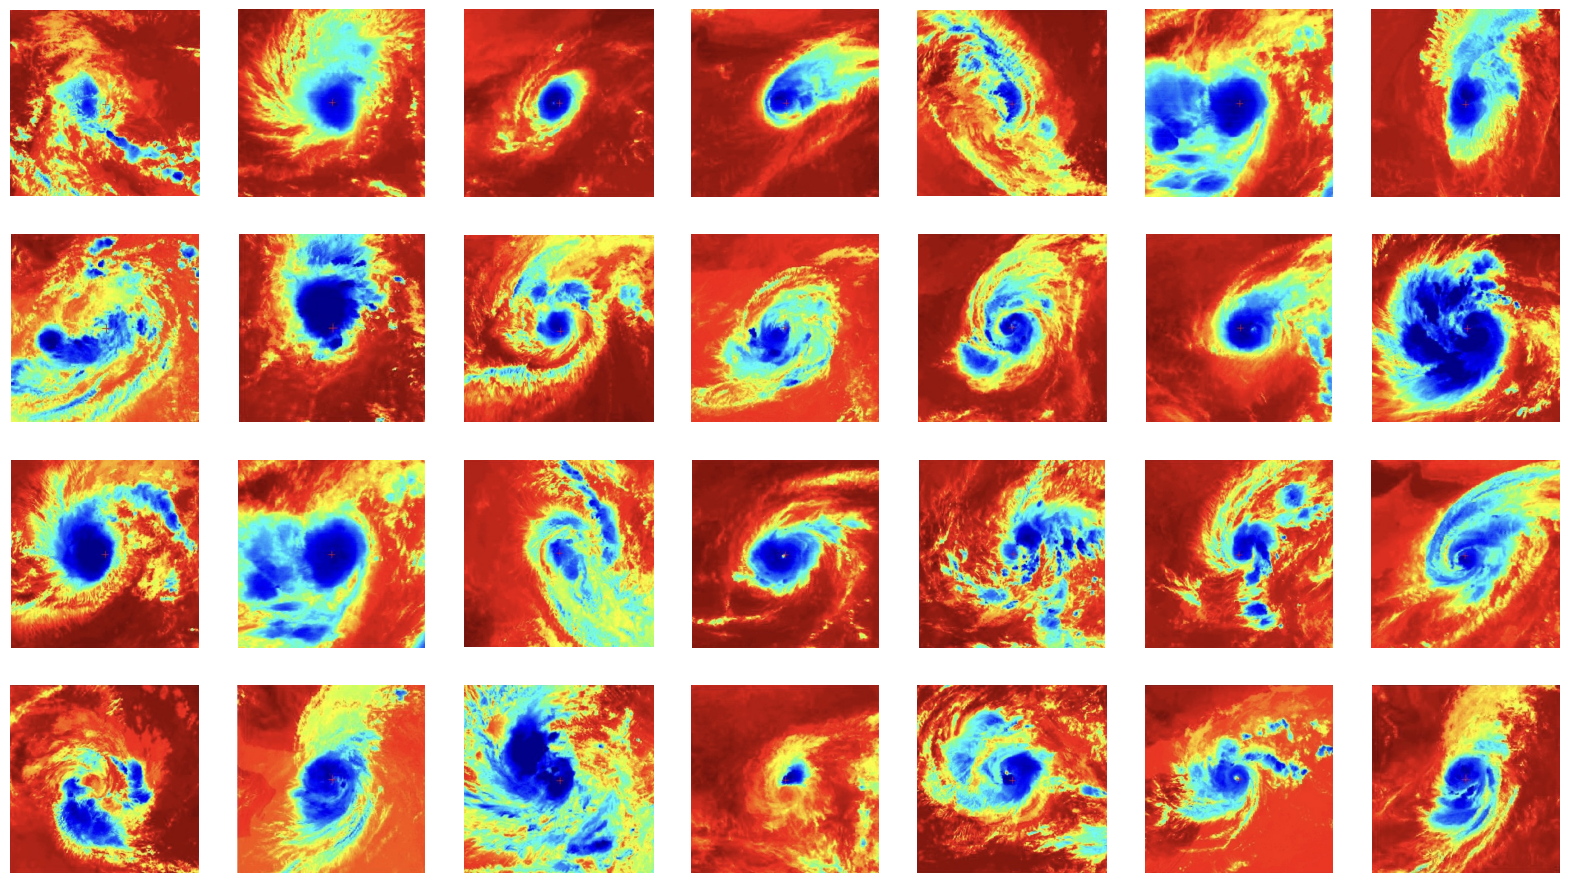

In [26]:
# Image Visualization
paths = glob.glob("/content/archive/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/*.jpg")
plt.figure(figsize=(20, 20))
for i in range(28):
    cur_img = mpimg.imread(paths[i])
    ax = plt.subplot(7, 7, i + 1)
    plt.imshow(cur_img.astype("uint8"))
    plt.axis("off")

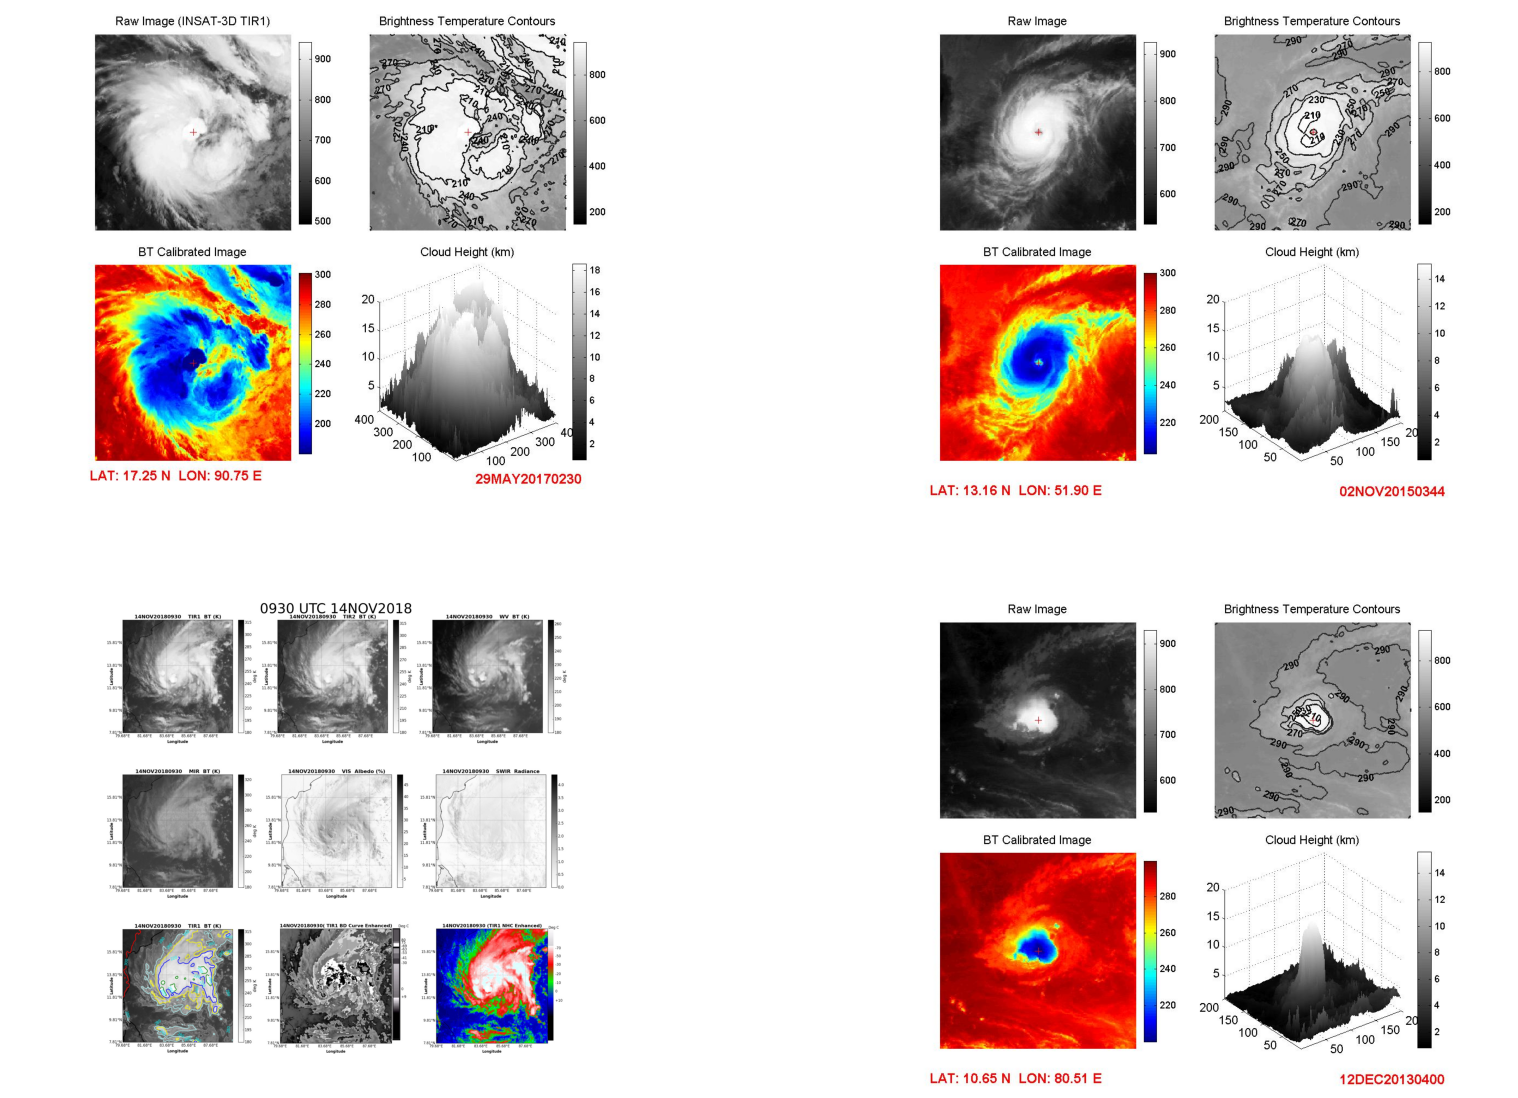

In [27]:
paths = glob.glob("/content/archive/insat3d_for_reference_ds/CYCLONE_DATASET/*.jpeg")
plt.figure(figsize=(20, 14))
for i in range(4):
    cur_img = mpimg.imread(paths[i])
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(cur_img.astype("uint8"))
    plt.axis("off")

In [6]:
# 3. Train-test split (80/20)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [7]:
# 4. Dataset class
class CycloneDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.file_names = dataframe['file_path'].values
        self.labels = dataframe['label'].values.astype(np.float32)
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        # Load image in RGB (simulate 3-channel from 1-channel IR)
        img = Image.open(self.file_names[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label


In [30]:
dataset = CycloneDataset(df)

In [31]:
dataset

In [32]:
dataset = CycloneDataset(df)
data_loader = DataLoader(dataset, batch_size=4, shuffle=True)

In [33]:
data_loader

In [57]:
# 5. Compute normalization stats on training data
from torchvision import transforms
from PIL import Image
import torch

class DebugTransform:
    def __call__(self, img):
        print(f"[Debug] Original image size: {img.size}")  # For PIL image
        return img

class TensorDebugTransform:
    def __call__(self, tensor):
        print(f"[Debug] Tensor shape: {tensor.shape}")  # For torch tensor
        print(f"[Debug] Min: {tensor.min():.4f}, Max: {tensor.max():.4f}")
        return tensor

# Combine your transforms with debugging
stats_transform = transforms.Compose([
    DebugTransform(),                         # Print original PIL image size
    transforms.Resize((250, 250)),
    transforms.ToTensor(),
    TensorDebugTransform()                    # Print tensor stats after ToTensor
])


In [58]:
train_stats_dataset = CycloneDataset(train_df, transform=stats_transform)
stats_loader = DataLoader(train_stats_dataset, batch_size=16, shuffle=False)
mean = torch.zeros(3)
std = torch.zeros(3)
nb_samples = 0
for imgs, _ in stats_loader:
    batch_samples = imgs.size(0)
    imgs = imgs.view(batch_samples, 3, -1)
    mean += imgs.mean(2).sum(0)
    std  += imgs.std(2).sum(0)
    nb_samples += batch_samples
mean /= nb_samples
std  /= nb_samples
mean = mean.tolist()
std  = std.tolist()


[Debug] Original image size: (360, 358)
[Debug] Tensor shape: torch.Size([3, 250, 250])
[Debug] Min: 0.0000, Max: 1.0000
[Debug] Original image size: (359, 354)
[Debug] Tensor shape: torch.Size([3, 250, 250])
[Debug] Min: 0.0000, Max: 1.0000
[Debug] Original image size: (358, 357)
[Debug] Tensor shape: torch.Size([3, 250, 250])
[Debug] Min: 0.0000, Max: 1.0000
[Debug] Original image size: (355, 356)
[Debug] Tensor shape: torch.Size([3, 250, 250])
[Debug] Min: 0.0000, Max: 1.0000
[Debug] Original image size: (356, 356)
[Debug] Tensor shape: torch.Size([3, 250, 250])
[Debug] Min: 0.0000, Max: 1.0000
[Debug] Original image size: (357, 358)
[Debug] Tensor shape: torch.Size([3, 250, 250])
[Debug] Min: 0.0000, Max: 1.0000
[Debug] Original image size: (356, 357)
[Debug] Tensor shape: torch.Size([3, 250, 250])
[Debug] Min: 0.0000, Max: 1.0000
[Debug] Original image size: (260, 262)
[Debug] Tensor shape: torch.Size([3, 250, 250])
[Debug] Min: 0.0000, Max: 1.0000
[Debug] Original image size: (35

In [59]:
# 6. Transforms (including normalization)
transform_train = transforms.Compose([
    transforms.Resize((250,250)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
transform_test = transforms.Compose([
    transforms.Resize((250,250)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [11]:
# 7. Create DataLoaders
train_dataset = CycloneDataset(train_df, transform=transform_train)
test_dataset  = CycloneDataset(test_df,  transform=transform_test)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

In [12]:
# 8. CNN Model Definition
class CycloneCNN(nn.Module):
    def __init__(self):
        super(CycloneCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 250->125
            nn.Conv2d(16,32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 125->62
            nn.Conv2d(32,64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 62->31
            nn.Conv2d(64,128,3, padding=1), nn.ReLU(), nn.MaxPool2d(2)   # 31->15
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*15*15, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

In [13]:
model = CycloneCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [53]:
val_loader = test_loader

In [54]:
# 9. Training Loop
num_epochs = 30
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation loop
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs.squeeze(), labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")


Epoch 1: Train Loss = 269.8094, Val Loss = 471.6865
Epoch 2: Train Loss = 252.7224, Val Loss = 458.4966
Epoch 3: Train Loss = 239.6654, Val Loss = 492.9419
Epoch 4: Train Loss = 253.0452, Val Loss = 564.1809
Epoch 5: Train Loss = 215.1726, Val Loss = 470.2783
Epoch 6: Train Loss = 221.9610, Val Loss = 474.2596
Epoch 7: Train Loss = 206.9546, Val Loss = 485.2635
Epoch 8: Train Loss = 191.9184, Val Loss = 525.6081
Epoch 9: Train Loss = 252.5077, Val Loss = 510.2449
Epoch 10: Train Loss = 234.7226, Val Loss = 495.9550
Epoch 11: Train Loss = 175.3175, Val Loss = 528.4044
Epoch 12: Train Loss = 225.0801, Val Loss = 498.2646
Epoch 13: Train Loss = 248.7797, Val Loss = 519.7729
Epoch 14: Train Loss = 221.5271, Val Loss = 585.5477
Epoch 15: Train Loss = 208.1175, Val Loss = 482.2302
Epoch 16: Train Loss = 166.9347, Val Loss = 489.2555
Epoch 17: Train Loss = 203.9940, Val Loss = 511.9173
Epoch 18: Train Loss = 181.4801, Val Loss = 582.2793
Epoch 19: Train Loss = 121.8608, Val Loss = 480.5762
Ep

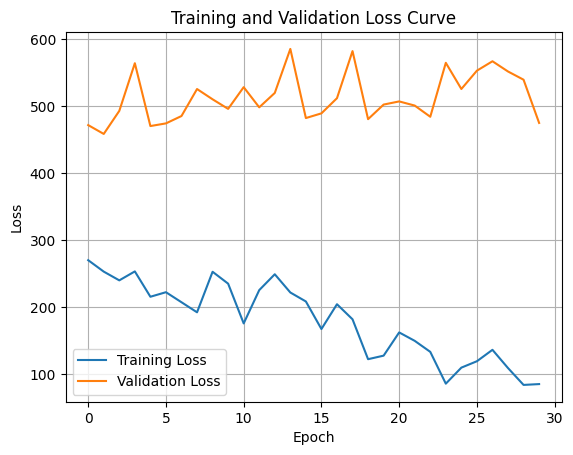

In [55]:
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
# 10. Evaluation on Test Set
model.eval()
preds = []
truth = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).view(-1,1)
        outputs = model(images)
        preds.extend(outputs.cpu().numpy().flatten())
        truth.extend(labels.cpu().numpy().flatten())
preds = np.array(preds)
truth = np.array(truth)
rmse = np.sqrt(np.mean((preds - truth)**2))
print(f"Test RMSE: {rmse:.2f} knots")

Test RMSE: 19.85 knots


In [16]:
# 11. Save model and normalization stats
torch.save(model.state_dict(), 'cyclone_model_state_dict.pt')
scripted_model = torch.jit.script(model)
scripted_model.save("cyclone_model.pt")
torch.save({'mean': mean, 'std': std}, 'norm_stats.pt')

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [35]:
model.eval()
preds = []
truth = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).view(-1, 1)
        outputs = model(images)
        preds.extend(outputs.cpu().numpy().flatten())
        truth.extend(labels.cpu().numpy().flatten())

preds = np.array(preds)
truth = np.array(truth)

# Compute evaluation metrics
rmse = np.sqrt(np.mean((preds - truth) ** 2))
mae = mean_absolute_error(truth, preds)
mse = mean_squared_error(truth, preds)
r2 = r2_score(truth, preds)

print(f"Test RMSE: {rmse:.2f} knots")
print(f"Test MAE: {mae:.2f} knots")
print(f"Test MSE: {mse:.2f} knots")
print(f"R-squared (R²): {r2:.2f}")


Test RMSE: 19.85 knots
Test MAE: 15.44 knots
Test MSE: 393.90 knots
R-squared (R²): 0.19


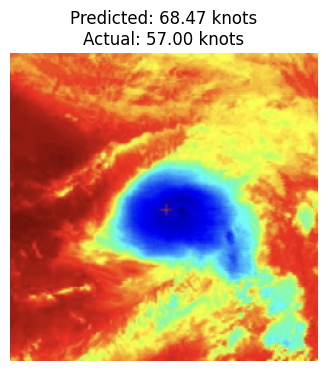

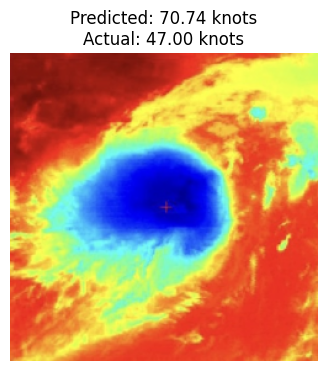

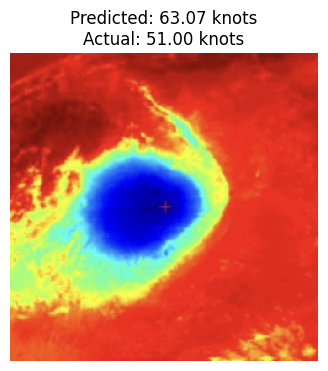

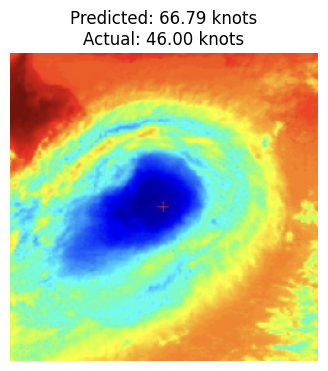

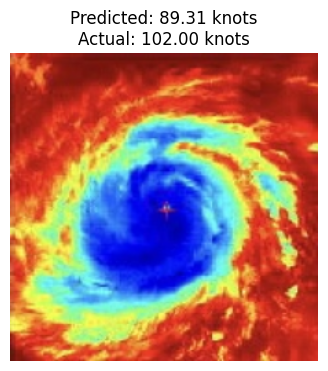

In [36]:
# Function to unnormalize and display images
def imshow(img, mean, std):
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean  # Unnormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

# Display a few test images with predictions
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)
outputs = model(images)
predicted = outputs.cpu().detach().numpy().flatten()
images = images.cpu()

# Assuming mean and std are lists with 3 elements each
for idx in range(5):  # Display first 5 images
    plt.figure(figsize=(4, 4))
    imshow(images[idx], mean, std)
    plt.title(f"Predicted: {predicted[idx]:.2f} knots\nActual: {labels[idx].item():.2f} knots")
    plt.show()


In [37]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Apr 30 18:31:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             30W /   70W |     712MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [38]:
import os
import torch

In [39]:
# Define the directory and file path
saved_dir = './saved_modelcyclone'
saved_path = os.path.join(saved_dir, 'model_state_dict.pt')


In [40]:
# Create the directory if it doesn't exist
os.makedirs(saved_dir, exist_ok=True)

In [42]:
# Save the model's state dictionary
torch.save(model.state_dict(), saved_path)

In [44]:
model.load_state_dict(torch.load(saved_path))

# Set the model to evaluation mode
model.eval()

CycloneCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=28800, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [66]:
from torchsummary import summary

summary(model, (3, 250, 250))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 250, 250]             448
              ReLU-2         [-1, 16, 250, 250]               0
         MaxPool2d-3         [-1, 16, 125, 125]               0
            Conv2d-4         [-1, 32, 125, 125]           4,640
              ReLU-5         [-1, 32, 125, 125]               0
         MaxPool2d-6           [-1, 32, 62, 62]               0
            Conv2d-7           [-1, 64, 62, 62]          18,496
              ReLU-8           [-1, 64, 62, 62]               0
         MaxPool2d-9           [-1, 64, 31, 31]               0
           Conv2d-10          [-1, 128, 31, 31]          73,856
             ReLU-11          [-1, 128, 31, 31]               0
        MaxPool2d-12          [-1, 128, 15, 15]               0
          Flatten-13                [-1, 28800]               0
           Linear-14                  [

In [67]:
from google.colab import files
files.download('saved_modelcyclone')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

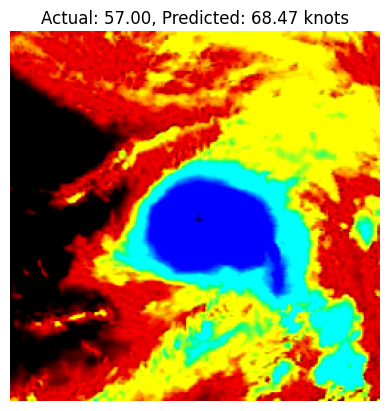

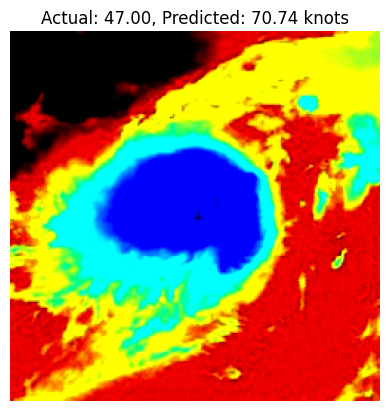

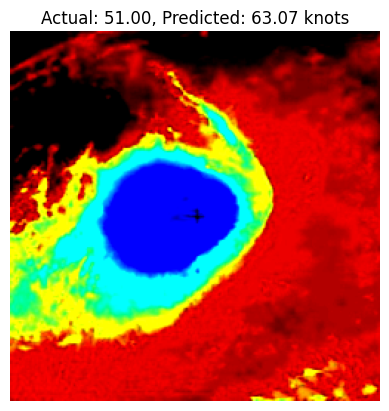

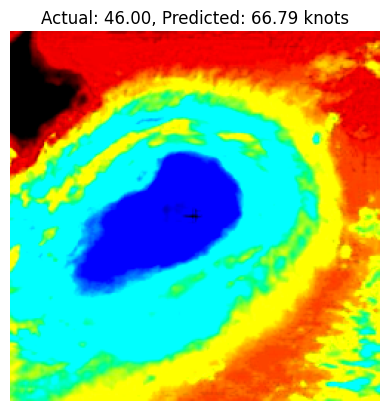

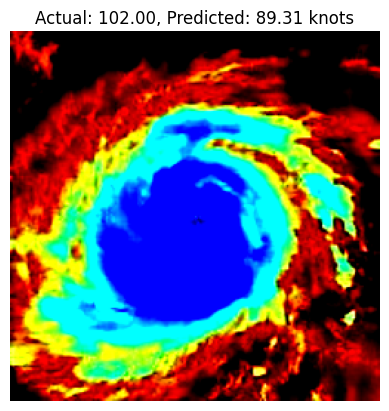

In [47]:
import os
import matplotlib.pyplot as plt

# Create output directory if it doesn't exist
os.makedirs("./output_images", exist_ok=True)

for idx in range(5):
    image, label = test_dataset[idx]
    image_input = image.unsqueeze(0).to(device)
    pred = model(image_input).item()

    # Convert to numpy image and transpose to HWC
    image_np = image.cpu().numpy().transpose(1, 2, 0)  # (C, H, W) → (H, W, C)

    # Optional: If grayscale, squeeze channel
    if image_np.shape[2] == 1:
        image_np = image_np.squeeze(2)

    plt.imshow(image_np, cmap='gray' if image_np.ndim == 2 else None)
    plt.title(f"Actual: {label:.2f}, Predicted: {pred:.2f} knots")
    plt.axis('off')
    plt.savefig(f"./output_images/img_{idx}_prediction.png")
    plt.show()



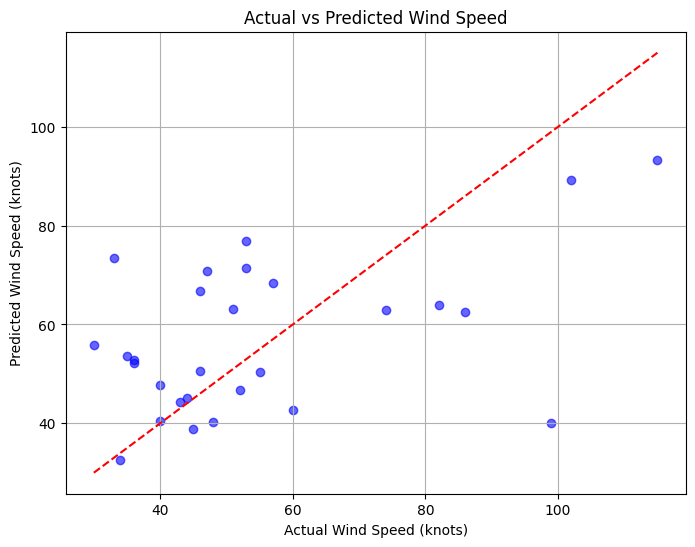

In [48]:
import matplotlib.pyplot as plt

# Assume `preds` and `truth` are lists of predicted and actual wind speeds
plt.figure(figsize=(8, 6))
plt.scatter(truth, preds, color='blue', alpha=0.6)
plt.plot([min(truth), max(truth)], [min(truth), max(truth)], color='red', linestyle='--')  # ideal line
plt.xlabel("Actual Wind Speed (knots)")
plt.ylabel("Predicted Wind Speed (knots)")
plt.title("Actual vs Predicted Wind Speed")
plt.grid(True)
plt.show()


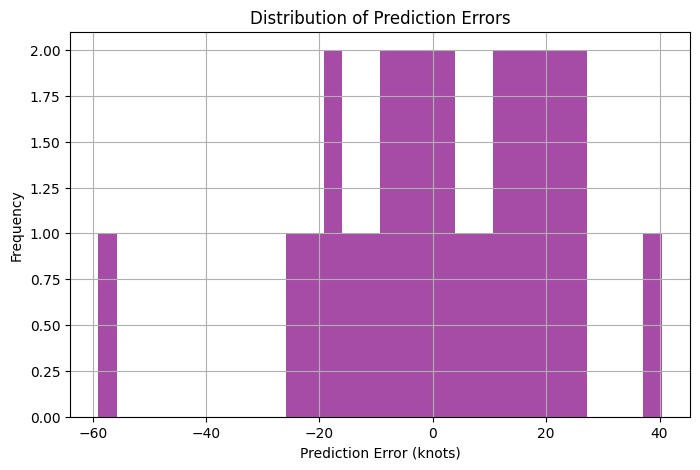

In [49]:
errors = [p - t for p, t in zip(preds, truth)]
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=30, color='purple', alpha=0.7)
plt.xlabel("Prediction Error (knots)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.grid(True)
plt.show()


In [62]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def visualize_feature_maps(model, image_tensor):
    # Ensure model is in eval mode
    model.eval()

    # Reshape and send to same device as model
    image_tensor = image_tensor.unsqueeze(0).to(device)

    x = image_tensor
    feature_maps = []

    # Manually apply each conv block in sequence to extract intermediate feature maps
    for layer in model.features:
        x = layer(x)
        if isinstance(layer, nn.Conv2d):  # Only store after conv layers
            feature_maps.append(x.cpu().detach())

    # Plot the first 8 feature maps from each conv layer
    for i, fmap in enumerate(feature_maps):
        plt.figure(figsize=(15, 4))
        for j in range(min(8, fmap.shape[1])):  # Only show 8 channels
            plt.subplot(1, 8, j+1)
            plt.imshow(fmap[0, j], cmap='viridis')
            plt.axis('off')
        plt.suptitle(f"Feature Maps after Conv Layer {i+1}")
        plt.show()

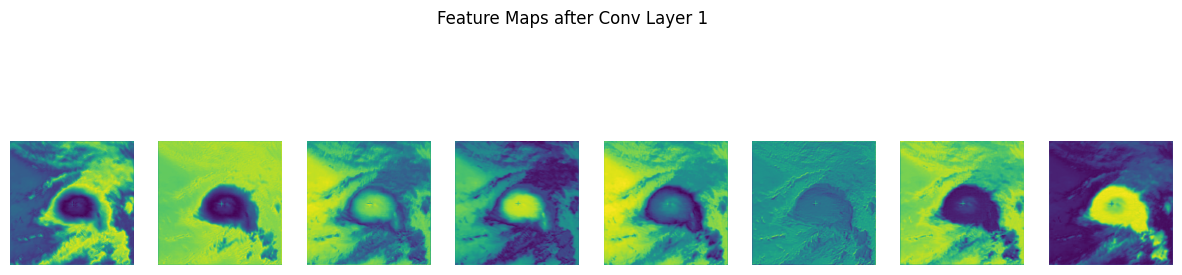

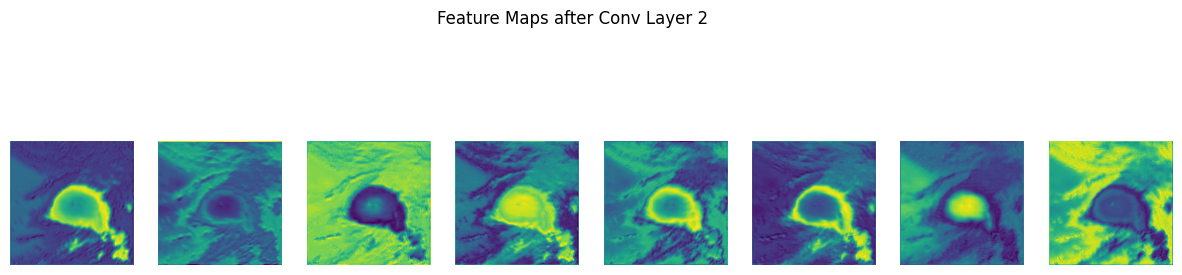

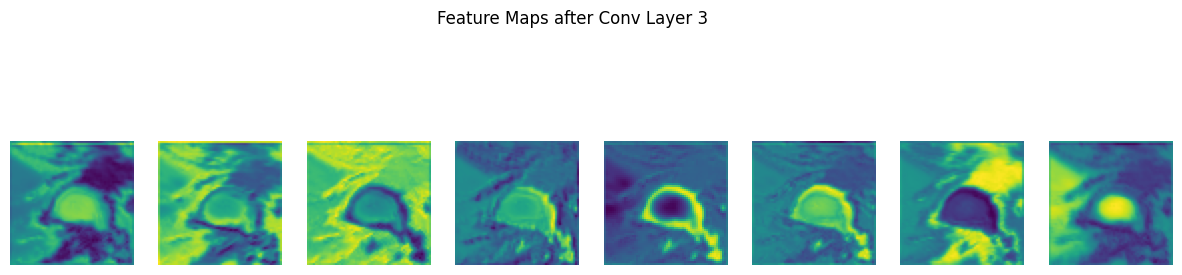

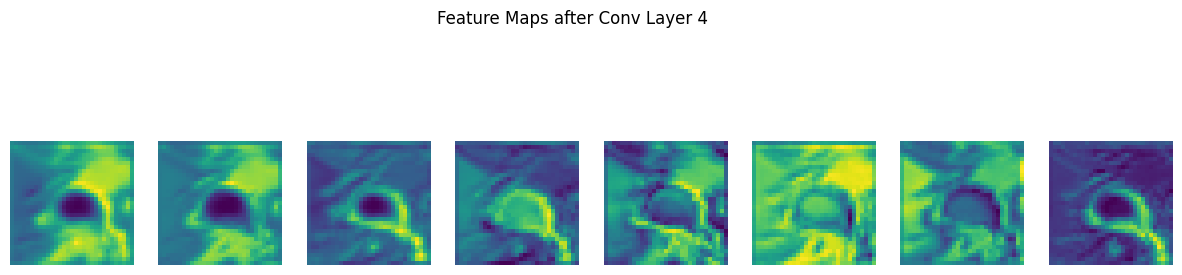

In [64]:
image, label = test_dataset[0]  # Single image and its label
visualize_feature_maps(model, image)